In [1]:
import numpy
import pandas as pd
import pysam
import plotly.express as px
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
def get_vcf_record_somatic(input_vcf, GT=True, somatic = False, heteroplasmic = False, tier = "HighConf"):
    vcf_input = pysam.VariantFile(input_vcf, "r")
    vcf_record = []

    for record in vcf_input:
        pos = record.pos
        ref = record.ref
        alt = record.alts[0]
        # vcf_record.append(pos)
        vcf_record.append("m.%d.%s>%s" %(pos, ref, alt))


    samples = [str(s) for s in vcf_input.header.samples if ":" not in s]
    sample_size = len(samples)
    sample_dict = dict(zip(samples, range(sample_size)))
    record_count = len(vcf_record)
    record_dict = dict(zip(vcf_record, range(record_count)))


    vcf_input = pysam.VariantFile(input_vcf, "r")
    matrix = numpy.zeros([record_count, sample_size])


    for record in vcf_input:
        record_index = record_dict["m.%d.%s>%s" %(record.pos, record.ref, record.alts[0])]
        for sample in samples:
            sample_index = [sample_dict[sample]]
            hf_value = record.samples[str(sample)]["AF"]
            GT_value = record.samples[str(sample)]["GT"][0]
            if record.samples[str(sample)]["Tier"] != tier:
                continue
            if heteroplasmic:
                if record.samples[str(sample)]["HeteroplasmyStatus"] != "hetero":
                    continue
            if somatic:
                if record.samples[str(sample)]["VariantOrigin"] != "somatic":
                    continue
            if pd.isna(hf_value):
                continue
            if GT:
                matrix[record_index, sample_index] = int(GT_value)
            else:
                matrix[record_index, sample_index] = float(hf_value)

    df = pd.DataFrame(matrix, columns = samples, index = vcf_record)
    return df



In [4]:
# code dict
df_manifest = pd.read_csv("/Users/suhang/Analysis/SMaHT_sample/SMHT001/smaht_manifest_2026-05-05-22h-41m.tsv", sep = "\t", header = 2)
code_dict = {}
for item in df_manifest['SampleTissues']:
    key, value = item.replace(" ", "").split("-")
    code_dict[key] = value
#code_dict = dict(zip(["-".join(i.split("-")[:2]) for i in df_manifest['SampleName'].tolist() if not pd.isna(i)],df_manifest['SampleTissues'].tolist()))



In [5]:
input_vcf = "../SMHT005_merge/p25_merged.vcf.gz"
df_het = get_vcf_record_somatic(input_vcf, GT=False, somatic=False, heteroplasmic=True)


/var/folders/3k/kdxfb4t50n54b_b94dmk6b2c0000gp/T/ipykernel_12561/339088031.py:151: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)


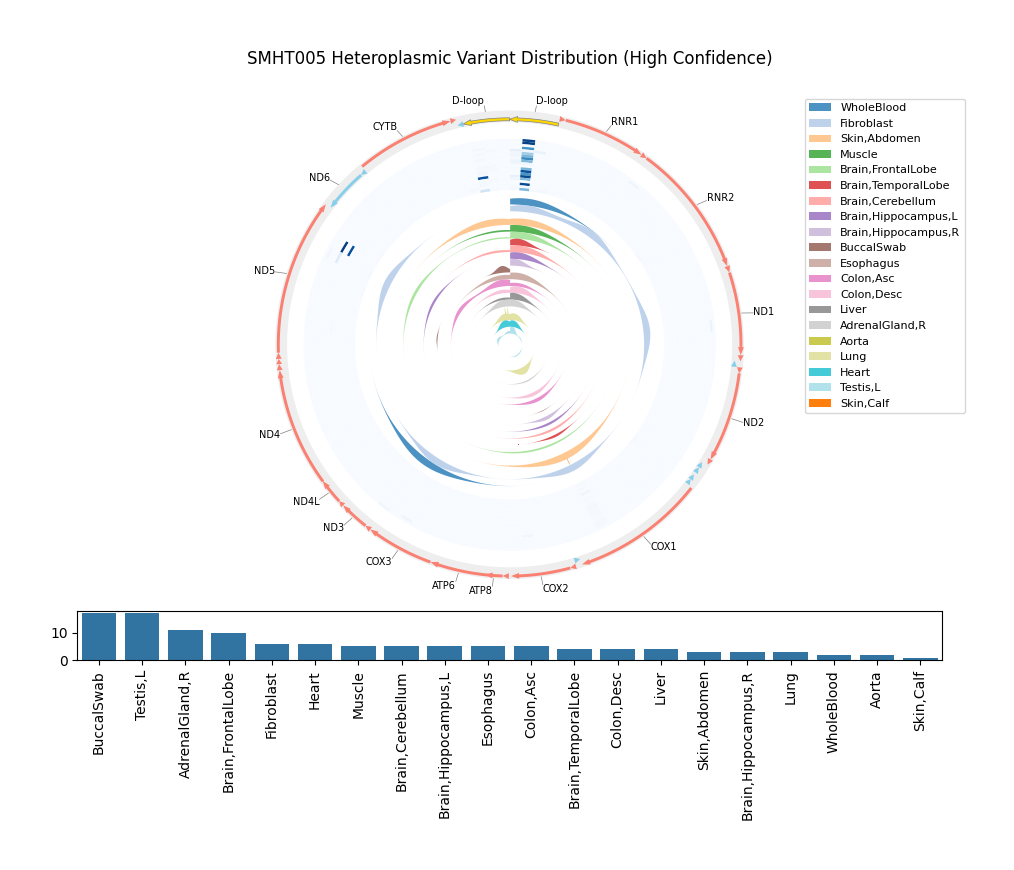

In [ ]:
# SNP, Indel, Haplotype Distribution
from pycirclize import Circos
from pycirclize.parser import Gff
from pycirclize.utils import load_eukaryote_example_dataset
import re
from pycirclize.utils import load_example_tree_file, ColorCycler
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import gridspec
from scipy.stats import gaussian_kde
import numpy

# --------------------- change here to adjust the subplot and layout ---------------------
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(nrows=2, ncols=1, width_ratios=[1], height_ratios=[10, 1])
# --------------------- ------------------------------------------------- ---------------------

ax1 = fig.add_subplot(gs[0, 0], polar=True)
ax2 = fig.add_subplot(gs[1, 0])

chrM_length = 16569
sector_dict = {"NC_012920.1": chrM_length}
circos = Circos(sector_dict)
chrM_sector = circos.sectors[0]

fontsize = 7
annotation_file = "/Users/suhang/Analysis/SMaHT_sample/SMHT001/summary/combined_per_tissue_vcfs_0416/rCRS.gff3"
gff = Gff(annotation_file)
startpos = 90
seqid2features = gff.get_seqid2features(feature_type="gene")
for sector in circos.sectors:
    cds_track = sector.add_track((startpos + 5, startpos + 10))
    cds_track.axis(fc="#EEEEEE", ec="none")
    features = seqid2features[sector.name]
    for feature in features:
        if feature.location.strand == 1:
            cds_track.genomic_features(feature, plotstyle="arrow",
                r_lim=(startpos + 7.5, startpos + 10), fc="salmon")
        else:
            cds_track.genomic_features(feature, plotstyle="arrow",
                r_lim=(startpos + 5, startpos + 7.5), fc="skyblue")
        start, end = int(feature.location.start), int(feature.location.end)
        label = feature.qualifiers.get("Name", [""])[0]
        if label == "" or label.startswith("hypothetical"):
            continue
        if feature.qualifiers.get('gene_biotype', [""])[0] == "tRNA":
            continue
        cds_track.annotate((start + end) / 2, label, label_size=7)

for feature in gff.extract_features("D_loop"):
    cds_track.genomic_features(feature, plotstyle="arrow",
        r_lim=(startpos + 5.0, startpos + 7.5), fc="gold", ec="grey", lw=0.5)
    cds_track.annotate((feature.location.start + feature.location.end) / 2,
        "D-loop", label_size=fontsize)

# ---------- data prep ----------
n_bins = 100
bin_edges = numpy.linspace(0, chrM_length, n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
tissues = df_het.columns.tolist()
n_tissues = len(tissues)

occ_mat = numpy.zeros((n_tissues, n_bins))   # variant count per bin
af_mat  = numpy.zeros((n_tissues, n_bins))   # summed AF per bin

for i, tid in enumerate(tissues):
    for record in df_het.index:
        val = df_het.loc[record, tid]
        if val < 0.01:
            continue
        pos = int(re.findall(r'\d+', record)[0])
        b = min(numpy.digitize(pos, bin_edges) - 1, n_bins - 1)
        occ_mat[i, b] += 1
        af_mat[i, b] += val

# normalize occurrence row-wise so each tissue is on [0, 1]
occ_norm = occ_mat / (occ_mat.max(axis=1, keepdims=True) + 1e-9)
# mean AF per bin (0 where no variant)
af_avg = numpy.where(occ_mat > 0, af_mat / (occ_mat + 1e-9), 0)

# # ---------- track 1: occurrence density heatmap (tissues × genomic bins) ----------
# hm_occ = chrM_sector.add_track((startpos - 22, startpos - 2))
# hm_occ.heatmap(occ_norm,  vmin=0, vmax=1, cmap="viridis")
ColorCycler.set_cmap("tab20")
group_name2color = {code_dict[col.split("-")[1]]: ColorCycler() for col in df_het.columns}

# ---------- track 2: mean AF heatmap ----------
hm_af = chrM_sector.add_track((startpos - 24, startpos - 2))
# hm_occ.heatmap(occ_norm,  vmin=0, vmax=1, cmap="viridis")
hm_af.heatmap(af_avg, vmin=0, vmax=1, cmap="Blues")
# df_sub = df_het.copy()
# hm_af.axis(fc="white",ec="black", lw=0.5, alpha = 0.1)
# for tid in df_sub.columns:
#     pos_list = []
#     var_list = []
#     for record in df_sub.index:
#         if df_sub.loc[record, tid] <0.01:
#             continue
#         pos = int(re.findall(r'\d+', record)[0])
#         pos_list.append(pos)
#         var_list.append(df_sub.loc[record, tid])
    #hm_af.scatter(pos_list, var_list, color = group_name2color[code_dict[tid.split("-")[1]]], s = 20)
    # pos_track.bar(x[1:], y, label = code_dict[col.split("-")[1]], width = 50)
    # y_ticks = list(range(0, max(y), 100))

# hm_af.heatmap(af_avg, vmin=0, vmax=1, cmap="Blues")

# ---------- track 3: per-tissue KDE fill_between ----------

spos = startpos - 27
width_t = max(1.5, (spos - 5) / n_tissues)
x_eval = numpy.linspace(0, chrM_length, 1000)
kde_top = spos
for tid in tissues:
    pos_list = [
        int(re.findall(r'\d+', r)[0])
        for r in df_het.index
        if df_het.loc[r, tid] >= 0.01
    ]
    color = group_name2color[code_dict[tid.split("-")[1]]]
    t = chrM_sector.add_track((spos - width_t, spos))
    t.axis(fc="white", ec="none", lw=0)
    if len(pos_list) >= 2:
        kde = gaussian_kde(pos_list, bw_method=0.08)
        density = kde(x_eval)
        density /= (density.max() + 1e-9)
        t.fill_between(x_eval, density, color=color, alpha=0.8,
                       label=code_dict[tid.split("-")[1]])
    elif len(pos_list) == 1:
        t.bar(pos_list, [0.5], color=color, width = 10,
                  label=code_dict[tid.split("-")[1]])
    spos -= width_t
kde_bottom = spos

# chrM_sector.text("Per-tissue KDE", r=(kde_top + kde_bottom) / 2,
#                  x=250, fontsize=5, ha="left", va="center")

fig = circos.plotfig(ax=ax1)
ax1.set_title("SMHT005 Heteroplasmic Variant Distribution (High Confidence)")
ax1.legend(bbox_to_anchor=(1.1, 1), fontsize=8, loc='upper left',
           borderaxespad=0., facecolor='white')




varnum = []
for col in df_het.columns:
    df_sub = df_het[col]
    df_sub = df_sub[df_sub > 0.01]
    varnum.append((code_dict[col.split("-")[1]], df_sub.shape[0]))
sorted_varnum = sorted(varnum, key=lambda x: x[1], reverse=True)
sns.barplot(x=[i[0] for i in sorted_varnum], y=[i[1] for i in sorted_varnum], ax=ax2)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.savefig("heat_mito_var_distribution.pdf")
